In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix, classification_report
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from datetime import timedelta

plt.rcParams['figure.figsize'] = (5,4)

In [2]:
productos = pd.read_csv(f"data/productos.csv", dtype={"codigo_unico": str}).rename(columns={"codigo_unico": "product"})
productos = productos.loc[:, ["product", "description", "brand", "category"]]
productos = productos.drop_duplicates("product")
productos['product'] = productos['product'].str.strip()

terceros = pd.read_csv(f"data/terceros_completo.csv", converters={"document": str})
terceros = terceros.drop_duplicates("document")
terceros = terceros.loc[:, ["document", "email", "telephone", "name"]]
terceros['document'] = terceros['document'].str.strip()



In [3]:
cols = [
    'date_sale',
    'id_point_sale',
    'identification_doct',
    'product',
    'invoice_value_with_discount_and_without_iva',
    'domicilio_status',
    'amount'
    
]

ventas = pd.read_csv(f"data/ventas_completo.csv", usecols=cols,
    dtype={
        'identification_doct': str,
        'product': str
    })
ventas['id_client'] = ventas['identification_doct'].str.strip()
mask = ventas["id_client"].str.isdigit()
df = ventas[mask]
df['product'] = df['product'].str.strip()

# 4. Convertir date_sale a datetime
df['date_sale'] = pd.to_datetime(
    df['date_sale'],
    errors='coerce',   
    dayfirst=True       # ajusta según tu formato (True si el CSV usa DD/MM/YYYY)
)

/var/folders/1g/77kw2x4j5678s_87_sqc1fpc0000gp/T/ipykernel_24535/2204615158.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['product'] = df['product'].str.strip()
/var/folders/1g/77kw2x4j5678s_87_sqc1fpc0000gp/T/ipykernel_24535/2204615158.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_sale'] = pd.to_datetime(


In [4]:
fecha_objetivo = '2025-04-15'
fecha_objetivo = pd.to_datetime(fecha_objetivo)

In [5]:
dos_meses_atras = df['date_sale'].max() - pd.Timedelta(days=65)

# 2. Preprocesamiento
df_unique = df.drop_duplicates(subset=['id_client', 'date_sale'])
df_recent = df_unique[df_unique['date_sale'] >= dos_meses_atras]

clientes_compras = df_recent.groupby('id_client')['date_sale'].count()
clientes_validos = clientes_compras[clientes_compras > 2].index
df_validos = df_recent[df_recent['id_client'].isin(clientes_validos)]

# 3. Cálculo de patrones de compra
df_validos = df_validos.sort_values(['id_client', 'date_sale'])
df_validos['days_between_purchases'] = df_validos.groupby('id_client')['date_sale'].diff().dt.days

agg = df_validos.groupby('id_client').agg(
last_purchase_date=('date_sale', 'max'),
    avg_days_between_purchases=('days_between_purchases', 'mean'),
    median_days_between_purchases=('days_between_purchases', 'mean'),
    std_days_between_purchases=('days_between_purchases', 'std')
).reset_index()

clientes_pather = agg.dropna() # Elimina clientes con 1 compra
clientes_pather["consistencia"] = 1/(clientes_pather["std_days_between_purchases"]+1)

clientes_pather['dias_since_last_purchase'] = (fecha_objetivo - clientes_pather['last_purchase_date']).dt.days

clientes_pather['lower_bound'] = clientes_pather['median_days_between_purchases'] - 3
clientes_pather['upper_bound'] = clientes_pather['median_days_between_purchases'] + 3

clientes_pather['potencial_compra'] = (
        (clientes_pather['dias_since_last_purchase'] >= clientes_pather['lower_bound']) &
        (clientes_pather['dias_since_last_purchase'] <= clientes_pather['upper_bound'])
    )

In [6]:
clientes_pather["potencial_compra"].value_counts()

False    49275
True     21702
Name: potencial_compra, dtype: int64

In [7]:
clientes_pather_baja_std = clientes_pather[clientes_pather["std_days_between_purchases"]<2]
clientes_pather_baja_std.shape

(7463, 10)

In [8]:
df_ventas = df[df["id_client"].isin(clientes_pather_baja_std["id_client"])]

In [9]:
df_ventas.shape

(5419816, 8)

In [13]:
df_ventas.head()

,date_sale,id_point_sale,identification_doct,invoice_value_with_discount_and_without_iva,domicilio_status,product,amount,id_client
75,2024-01-01,MIX,1020489925,1508.0,False,108959,1.00,1020489925
136,2024-01-01,MIX,43535911,10673.0,False,81586,1.00,43535911
137,2024-01-01,MIX,43535911,10673.0,False,81569,1.16,43535911
138,2024-01-01,MIX,43535911,10673.0,False,81601,0.91,43535911
139,2024-01-01,MIX,43535911,10673.0,False,81388,0.44,43535911


In [14]:
agg_  = dict(
    #productos_distintos = ('product', 'unique'),
    cantidad_productos = ('amount', 'sum'),
    tot_pago=("invoice_value_with_discount_and_without_iva", "sum")
)

df_work = df_ventas.groupby(['id_client', 'date_sale', 'product']).agg(**agg_).reset_index()
#'id_point_sale', 


In [16]:
df_work.to_parquet("data_work.parquet")

In [11]:
daily = (df_work.groupby(['id_client','date_sale'], as_index=False)
            .agg(qty_tot=('cantidad_productos','sum'),
                 amount_tot=('tot_pago','sum'),
                 skus=('product','nunique'))
            .assign(purchased=1)
            .rename(columns={'id_client':'client','date_sale':'date'}))
daily.head()

,client,date,qty_tot,amount_tot,skus,purchased
0,1000083699,2024-01-21,76.680,25025000.0,55,1
1,1000083699,2024-03-03,69.062,22988450.0,50,1
2,1000083699,2024-03-17,75.680,29249012.0,61,1
3,1000083699,2024-04-07,99.230,69591030.0,85,1
4,1000083699,2024-05-13,91.165,41981590.0,71,1


In [13]:
daily.shape

(619269, 6)

In [14]:
daily.to_csv("daily_new.csv", index=False)

In [15]:
min_date = daily['date'].min()
# TODO: PONER FEchas de forma dinámica
future_dates = pd.date_range('2025-04-14','2025-04-30',freq='D') #'2025-04-01'

full_idx = pd.MultiIndex.from_product(
    [daily['client'].unique(),
     pd.date_range(min_date, future_dates.max(), freq='D')],
    names=['client','date'])

calendar = (daily.set_index(['client','date'])
            .reindex(full_idx, fill_value=0)
            .reset_index())

# Features de fecha
calendar['dow'] = calendar['date'].dt.dayofweek
calendar['dom'] = calendar['date'].dt.day
calendar['month'] = calendar['date'].dt.month
calendar['is_weekend'] = calendar['dow'].isin([5,6]).astype(int)
calendar['is_quincena'] = (calendar['dom'].isin([28, 29, 30, 31, 1, 2, 13, 14, 15, 16])).astype(int)

# Recencia
# Recencia  (versión sin warning)
calendar.sort_values(['client', 'date'], inplace=True)

calendar['prev_buy'] = (
    calendar
      .groupby('client', group_keys=False)['date']        #  ← aquí el cambio
      .apply(lambda s: s.where(calendar.loc[s.index, 'purchased'].eq(1)).ffill())
)

calendar['days_since_last'] = (
    (calendar['date'] - calendar['prev_buy']).dt.days.fillna(9999).astype(int)
)
calendar.drop(columns='prev_buy', inplace=True)


# Ventanas móviles
for w in [1,3,7,15,30]:
    calendar[f'cnt_{w}d'] = (calendar.groupby('client')['purchased']
                             .transform(lambda x: x.rolling(w,min_periods=1).sum().shift(1).fillna(0)))

calendar.head()

,client,date,qty_tot,amount_tot,skus,purchased,dow,dom,month,is_weekend,is_quincena,days_since_last,cnt_1d,cnt_3d,cnt_7d,cnt_15d,cnt_30d
0,1000083699,2024-01-01,0.0,0.0,0,0,0,1,1,0,1,9999,0.0,0.0,0.0,0.0,0.0
1,1000083699,2024-01-02,0.0,0.0,0,0,1,2,1,0,1,9999,0.0,0.0,0.0,0.0,0.0
2,1000083699,2024-01-03,0.0,0.0,0,0,2,3,1,0,0,9999,0.0,0.0,0.0,0.0,0.0
3,1000083699,2024-01-04,0.0,0.0,0,0,3,4,1,0,0,9999,0.0,0.0,0.0,0.0,0.0
4,1000083699,2024-01-05,0.0,0.0,0,0,4,5,1,0,0,9999,0.0,0.0,0.0,0.0,0.0


In [16]:
calendar.to_csv("calendar_new.csv", index=False)

In [17]:
calendar['purchased'].value_counts(normalize=True)

0    0.829262
1    0.170738
Name: purchased, dtype: float64

In [18]:
max_hist = daily["date"].max() 
train_mask = calendar["date"] <= max_hist - pd.Timedelta(days=30)
valid_mask = (calendar["date"] > max_hist - pd.Timedelta(days=30)) & \
             (calendar["date"] <= max_hist)
features = [
    'dow',
    'dom',
    'month',
    'is_weekend','is_quincena',
            'days_since_last'] + [f'cnt_{w}d' for w in [1,3,7,15,30]
                                  ]

X_train, y_train = calendar.loc[train_mask, features], calendar.loc[train_mask,'purchased']
X_valid, y_valid = calendar.loc[valid_mask, features], calendar.loc[valid_mask,'purchased']
print(X_train.shape, X_valid.shape)

(3283720, 11) (223890, 11)


In [19]:
print(y_valid.value_counts(normalize=True)) 

0    0.779745
1    0.220255
Name: purchased, dtype: float64


In [20]:
pipe = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(
        solver='saga',
        max_iter=100,
        tol=1e-3,
        C=0.1,
        class_weight='balanced',
        n_jobs=-1
    )
)
pipe.fit(X_train, y_train)
print('Iteraciones:', pipe.named_steps['logisticregression'].n_iter_[0])

Iteraciones: 29


In [21]:
y_pred = pipe.predict(X_valid)
y_prob = pipe.predict_proba(X_valid)[:,1]
print('ROC-AUC:', roc_auc_score(y_valid,y_prob).round(3))
print('Brier :', brier_score_loss(y_valid,y_prob).round(3))
print('Confusion\n', confusion_matrix(y_valid,y_pred))
print(classification_report(y_valid,y_pred, digits=3)) #0.05---->bir 0.11, 4410

ROC-AUC: 0.836
Brier : 0.211
Confusion
 [[119429  55148]
 [  7329  41984]]
              precision    recall  f1-score   support

           0      0.942     0.684     0.793    174577
           1      0.432     0.851     0.573     49313

    accuracy                          0.721    223890
   macro avg      0.687     0.768     0.683    223890
weighted avg      0.830     0.721     0.744    223890



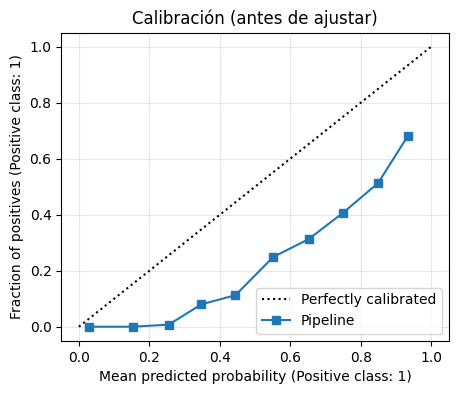

In [22]:
CalibrationDisplay.from_estimator(pipe, X_valid, y_valid, n_bins=10, strategy='uniform')
plt.title('Calibración (antes de ajustar)')
plt.grid(alpha=0.3)
plt.show()

In [23]:
cal = CalibratedClassifierCV(pipe, method='sigmoid', cv='prefit')
cal.fit(X_valid, y_valid)
y_prob_cal = cal.predict_proba(X_valid)[:,1]
print('Brier tras calibrar:', brier_score_loss(y_valid, y_prob_cal).round(3))

Brier tras calibrar: 0.129


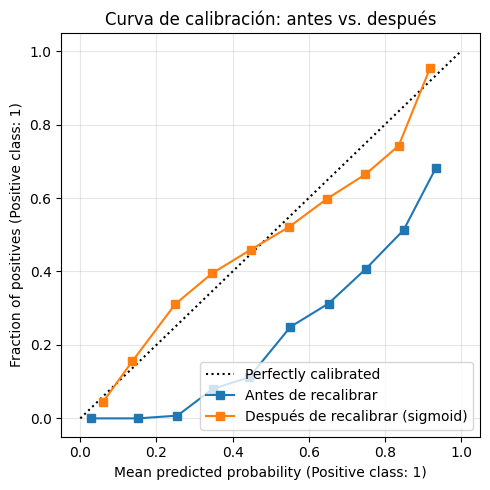

In [24]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(5, 5))

# --- Curva del modelo sin recalibrar ---
CalibrationDisplay.from_estimator(
    pipe,                # modelo base (pipeline)
    X_valid, y_valid,
    n_bins=10,
    strategy="uniform",
    name="Antes de recalibrar",
    ax=ax
)

# --- Curva del modelo recalibrado ---
CalibrationDisplay.from_estimator(
    cal,                 # modelo calibrado con Platt
    X_valid, y_valid,
    n_bins=10,
    strategy="uniform",
    name="Después de recalibrar (sigmoid)",
    ax=ax
)

ax.set_title("Curva de calibración: antes vs. después")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)



prec, rec, thresholds = precision_recall_curve(y_valid, y_prob)


threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)

precision = precision_score(y_valid, y_pred)  # ≈ 0.59
recall    = recall_score(y_valid, y_pred)     # ≈ 0.26

print(f'Precisión: {precision:.2%}, Recall: {recall:.2%}')


cm = confusion_matrix(y_valid, y_pred)
print(cm)

print(classification_report(y_valid, y_pred, digits=3))


Precisión: 43.22%, Recall: 85.14%
[[119429  55148]
 [  7329  41984]]
              precision    recall  f1-score   support

           0      0.942     0.684     0.793    174577
           1      0.432     0.851     0.573     49313

    accuracy                          0.721    223890
   macro avg      0.687     0.768     0.683    223890
weighted avg      0.830     0.721     0.744    223890



In [32]:
future_df = calendar[calendar['date']=='2025-04-16'].copy()
future_df['prob'] = cal.predict_proba(future_df[features])[:,1]
high = future_df[future_df['prob']>=0.50].sort_values(['date','prob'], ascending=[True,False])
high[["client", "prob"]]

,client,prob
931647,1235245925,0.926480
2642367,64585834,0.926480
3169677,800180330,0.926480
3363591,900078057,0.926480
3431145,901569974,0.926480
...,...,...
3503559,98493937,0.501945
3531747,98545507,0.501945
273603,1032248954,0.500784
2808093,70556431,0.500784


In [34]:
high.to_csv("data/client_16_april.csv", index=False)

In [27]:
back = pd.read_csv("data/ventas_backtesting_exploted.csv")
back["date_sale"] = pd.to_datetime(back["date_sale"])
back["client"] = back["identification_doct"].astype(str).str.strip()

mask = back["client"].str.isdigit()
back = back[mask]

clientes_existentes = calendar["client"].unique()
back_old = back[back["client"].isin(clientes_existentes)]
new = back[~back["client"].isin(clientes_existentes)]
new["client"].nunique(), back_old["client"].nunique()

/var/folders/1g/77kw2x4j5678s_87_sqc1fpc0000gp/T/ipykernel_27433/966289315.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  back = pd.read_csv("data/ventas_backtesting_exploted.csv")


(39489, 4031)

In [28]:
def back_testing(cut=0.5, date_back='2025-04-20'):
    future_df = calendar[calendar['date']==date_back].copy()
    future_df['prob'] = cal.predict_proba(future_df[features])[:,1]
    high = future_df[future_df['prob']>=cut].sort_values(['date','prob'], ascending=[True,False])
   
    back_old_test = back_old[back_old["date_sale"]==date_back]
    back_old_test = back_old_test[["client", "date_sale"]].drop_duplicates()
    
    rev = pd.merge(back_old_test, high, on='client', how='outer', indicator=True)
    return rev["_merge"].value_counts()




In [29]:
back_testing(cut=0.5, date_back='2025-04-21')

left_only     483
right_only     96
both           48
Name: _merge, dtype: int64

In [30]:
616/(908+616)

0.4041994750656168

In [31]:
back_old.groupby(["date_sale",]).agg({"client": "nunique"})

,client
date_sale,
2025-04-15,1524
2025-04-16,1838
2025-04-17,1214
2025-04-18,1019
2025-04-19,1334
2025-04-20,1276
2025-04-21,531
